In [1]:
# Phase 6 – SR Design (Structural Resilience Ranking)
# Cell 1: Setup + Load Feature Matrix from Phase 5

from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

# ---------------------- Paths ----------------------
PROJECT = Path(r"D:\univercity\omid_project\economics_project")

PHASE5_DATA = PROJECT / "outputs" / "phase5" / "data"
OUT_DIR     = PROJECT / "outputs" / "phase6"

OUT_DATA  = OUT_DIR / "data"
OUT_TAB   = OUT_DIR / "tables"
OUT_FIG   = OUT_DIR / "figures"
OUT_LOG   = OUT_DIR / "logs"

for d in [OUT_DATA, OUT_TAB, OUT_FIG, OUT_LOG]:
    d.mkdir(parents=True, exist_ok=True)

print("=" * 60)
print("Phase 6 – SR Design | Cell 1")
print("=" * 60)
print(f"Timestamp     : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Project Root  : {PROJECT}")
print(f"Outputs       : {OUT_DIR}")
print()

# Load Feature Matrix
feature_matrix = pd.read_pickle(PHASE5_DATA / "feature_matrix.pkl")

print("Loaded Feature Matrix:")
print(f"  Shape   : {feature_matrix.shape}")
print(f"  Columns : {len(feature_matrix.columns)}")
print(f"  Sample columns: {feature_matrix.columns.tolist()[:10]}")
print("\nCell 1 completed successfully.")

Phase 6 – SR Design | Cell 1
Timestamp     : 2026-09-23 10:59:16
Project Root  : D:\univercity\omid_project\economics_project
Outputs       : D:\univercity\omid_project\economics_project\outputs\phase6

Loaded Feature Matrix:
  Shape   : (2718, 45)
  Columns : 45
  Sample columns: ['country', 'year', 'betweenness_BankingSector', 'betweenness_CentralBank', 'betweenness_Government', 'betweenness_Household', 'betweenness_Industry', 'closeness_BankingSector', 'closeness_CentralBank', 'closeness_Government']

Cell 1 completed successfully.


In [2]:
# Phase 6 – SR Design
# Cell 2: Construct Structural Resilience (SR) Score

import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_DATA = PROJECT / "outputs" / "phase6" / "data"
OUT_TAB  = PROJECT / "outputs" / "phase6" / "tables"

feature_matrix = pd.read_pickle(PROJECT / "outputs" / "phase5" / "data" / "feature_matrix.pkl")

print("=" * 60)
print("Phase 6 – SR Design | Cell 2")
print("Constructing Structural Resilience Score")
print("=" * 60)

nodes = ["Government", "CentralBank", "BankingSector", "Industry", "Household"]

# Centrality metrics to use for SR
centrality_metrics = ["pagerank", "betweenness", "closeness", "in_strength", "out_strength", "katz"]

# Build SR for each node
sr_records = []

for node in nodes:
    cols = []
    for m in centrality_metrics:
        col_name = f"{m}_{node}"
        if col_name in feature_matrix.columns:
            cols.append(col_name)
    
    if not cols:
        continue
    
    # Extract and scale
    node_features = feature_matrix[cols].copy()
    
    # Replace inf/nan
    node_features = node_features.replace([np.inf, -np.inf], np.nan)
    node_features = node_features.fillna(node_features.median())
    
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(node_features)
    scaled_df = pd.DataFrame(scaled, columns=cols)
    
    # SR score = mean of scaled centralities
    sr_score = scaled_df.mean(axis=1)
    
    temp = feature_matrix[["country", "year"]].copy()
    temp["node"] = node
    temp["SR"] = sr_score.values
    sr_records.append(temp)

sr_df = pd.concat(sr_records, ignore_index=True)

print(f"\nSR records created: {len(sr_df)}")
print(sr_df.head(10).to_string(index=False))

# Save long format
sr_df.to_pickle(OUT_DATA / "sr_long.pkl")
sr_df.to_csv(OUT_TAB / "sr_long.csv", index=False)

# Wide format (one column per node)
sr_wide = sr_df.pivot_table(index=["country", "year"], columns="node", values="SR").reset_index()
sr_wide.columns.name = None
sr_wide.to_pickle(OUT_DATA / "sr_wide.pkl")
sr_wide.to_csv(OUT_TAB / "sr_wide.csv", index=False)

print(f"\nSaved SR long  → {OUT_DATA / 'sr_long.pkl'}")
print(f"Saved SR wide  → {OUT_DATA / 'sr_wide.pkl'}")
print(f"SR wide shape  : {sr_wide.shape}")

print("\nCell 2 completed successfully.")

Phase 6 – SR Design | Cell 2
Constructing Structural Resilience Score

SR records created: 13590
  country  year       node       SR
Australia  1870 Government 0.323593
Australia  1871 Government 0.326487
Australia  1872 Government 0.323333
Australia  1873 Government 0.321466
Australia  1874 Government 0.325972
Australia  1875 Government 0.327403
Australia  1876 Government 0.318444
Australia  1877 Government 0.317525
Australia  1878 Government 0.316395
Australia  1879 Government 0.319504

Saved SR long  → D:\univercity\omid_project\economics_project\outputs\phase6\data\sr_long.pkl
Saved SR wide  → D:\univercity\omid_project\economics_project\outputs\phase6\data\sr_wide.pkl
SR wide shape  : (2718, 7)

Cell 2 completed successfully.


Phase 6 – SR Design | Cell 3
Ranking Institutions & Critical Node Identification

--- Overall SR Ranking of Institutions ---
         node     mean      std   median  rank
   Government 0.295170 0.081721 0.288083     1
BankingSector 0.199377 0.081612 0.212605     2
     Industry 0.197595 0.081501 0.197268     3
    Household 0.193984 0.059776 0.184490     4
  CentralBank 0.077733 0.028245 0.070588     5

--- Sample Yearly SR by Node ---
 year          node       SR
 1870 BankingSector 0.263919
 1870   CentralBank 0.114088
 1870    Government 0.238424
 1870     Household 0.217697
 1870      Industry 0.177390
 1871 BankingSector 0.255395
 1871   CentralBank 0.105629
 1871    Government 0.246741
 1871     Household 0.207420
 1871      Industry 0.194696
 1872 BankingSector 0.256316
 1872   CentralBank 0.107170
 1872    Government 0.246811
 1872     Household 0.213960
 1872      Industry 0.200687

--- Top Critical Node per Country (sample) ---
    country       node       SR
Switzerland Gov

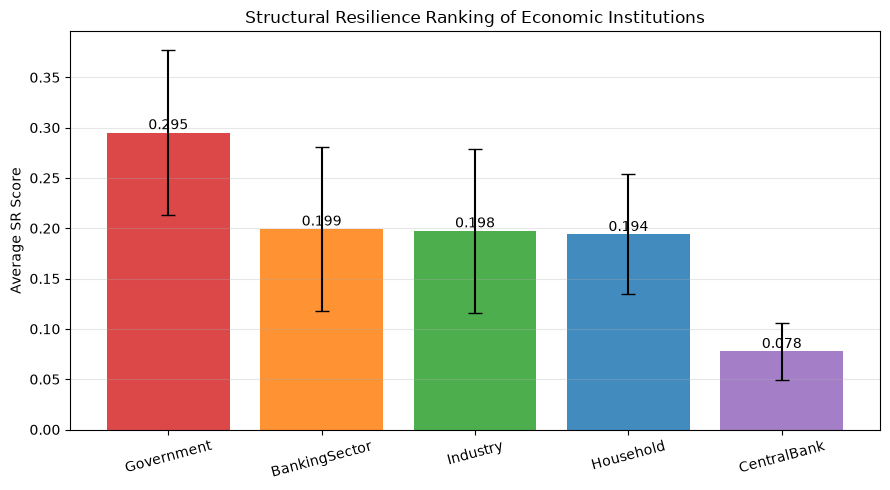

Saved figure → D:\univercity\omid_project\economics_project\outputs\phase6\figures\sr_overall_ranking.png

Cell 3 completed successfully.


In [3]:
# Phase 6 – SR Design
# Cell 3: Rank Institutions & Identify Critical Nodes

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_DATA = PROJECT / "outputs" / "phase6" / "data"
OUT_TAB  = PROJECT / "outputs" / "phase6" / "tables"
OUT_FIG  = PROJECT / "outputs" / "phase6" / "figures"

sr_long = pd.read_pickle(OUT_DATA / "sr_long.pkl")
sr_wide = pd.read_pickle(OUT_DATA / "sr_wide.pkl")

print("=" * 60)
print("Phase 6 – SR Design | Cell 3")
print("Ranking Institutions & Critical Node Identification")
print("=" * 60)

# ---------------------- Overall average SR by node ----------------------
node_avg = sr_long.groupby("node")["SR"].agg(["mean", "std", "median"]).reset_index()
node_avg = node_avg.sort_values("mean", ascending=False)
node_avg["rank"] = range(1, len(node_avg) + 1)

print("\n--- Overall SR Ranking of Institutions ---")
print(node_avg.to_string(index=False))

node_avg.to_csv(OUT_TAB / "sr_node_ranking_overall.csv", index=False)

# ---------------------- Ranking per year (average across countries) ----------------------
yearly_node = sr_long.groupby(["year", "node"])["SR"].mean().reset_index()
yearly_rank = yearly_node.copy()
yearly_rank["rank"] = yearly_rank.groupby("year")["SR"].rank(ascending=False)

print("\n--- Sample Yearly SR by Node ---")
print(yearly_node.head(15).to_string(index=False))

yearly_node.to_csv(OUT_TAB / "sr_yearly_by_node.csv", index=False)
yearly_rank.to_csv(OUT_TAB / "sr_yearly_rank.csv", index=False)

# ---------------------- Ranking per country (average over years) ----------------------
country_node = sr_long.groupby(["country", "node"])["SR"].mean().reset_index()
country_rank = country_node.copy()
country_rank["rank"] = country_rank.groupby("country")["SR"].rank(ascending=False)

country_node.to_csv(OUT_TAB / "sr_country_by_node.csv", index=False)
country_rank.to_csv(OUT_TAB / "sr_country_rank.csv", index=False)

print("\n--- Top Critical Node per Country (sample) ---")
top_nodes = country_rank[country_rank["rank"] == 1][["country", "node", "SR"]].sort_values("SR", ascending=False)
print(top_nodes.head(18).to_string(index=False))

# ---------------------- Bar plot of overall ranking ----------------------
plt.figure(figsize=(9, 5))
colors = ["#d62728", "#ff7f0e", "#2ca02c", "#1f77b4", "#9467bd"]
bars = plt.bar(node_avg["node"], node_avg["mean"], yerr=node_avg["std"],
               color=colors[:len(node_avg)], alpha=0.85, capsize=5)
plt.ylabel("Average SR Score")
plt.title("Structural Resilience Ranking of Economic Institutions")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, node_avg["mean"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{val:.3f}",
             ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.savefig(OUT_FIG / "sr_overall_ranking.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved figure → {OUT_FIG / 'sr_overall_ranking.png'}")

print("\nCell 3 completed successfully.")

Phase 6 – SR Design | Cell 4
Merge SR + Temporal Trends
Feature Matrix + SR shape: (2718, 50)
Saved → D:\univercity\omid_project\economics_project\outputs\phase6\data\feature_matrix_with_sr.pkl

--- Yearly SR (sample) ---
node  BankingSector  CentralBank  Government  Household  Industry
year                                                             
1870          0.264        0.114       0.238      0.218     0.177
1871          0.255        0.106       0.247      0.207     0.195
1872          0.256        0.107       0.247      0.214     0.201
1873          0.257        0.108       0.261      0.215     0.208
1874          0.263        0.105       0.256      0.213     0.204
1875          0.257        0.103       0.259      0.209     0.208
1876          0.256        0.103       0.260      0.211     0.210
1877          0.255        0.101       0.261      0.214     0.209


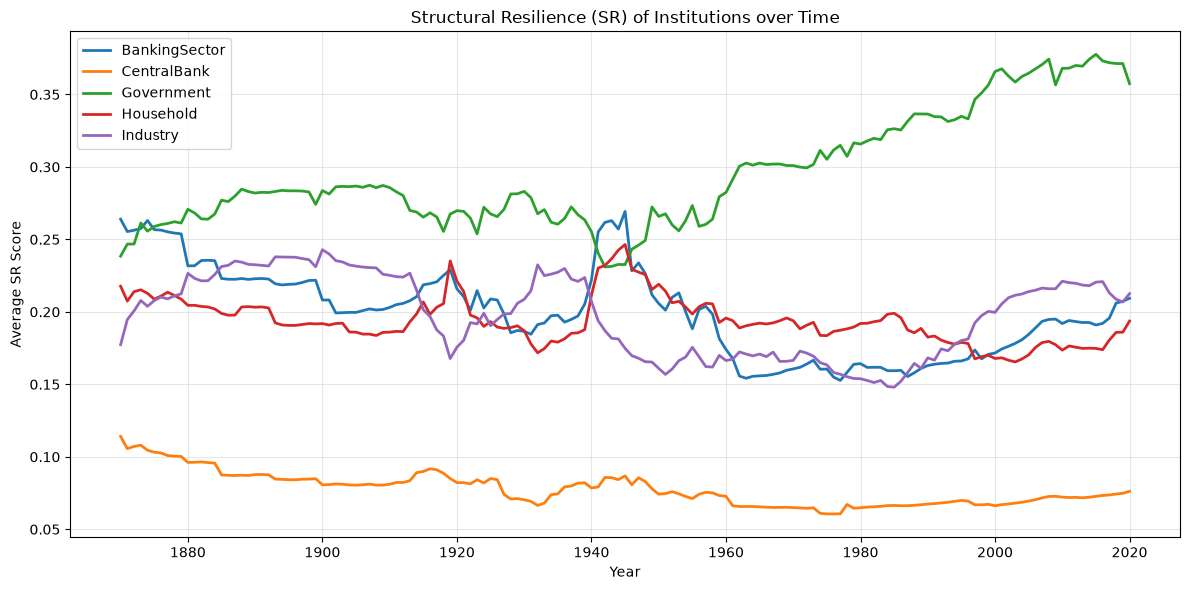

Saved figure → D:\univercity\omid_project\economics_project\outputs\phase6\figures\sr_temporal_trends.png
Saved country SR matrix → D:\univercity\omid_project\economics_project\outputs\phase6\tables\sr_country_avg_matrix.csv

Cell 4 completed successfully.


In [4]:
# Phase 6 – SR Design
# Cell 4: Merge SR with Feature Matrix + Temporal SR Trends

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_DATA = PROJECT / "outputs" / "phase6" / "data"
OUT_TAB  = PROJECT / "outputs" / "phase6" / "tables"
OUT_FIG  = PROJECT / "outputs" / "phase6" / "figures"

sr_wide = pd.read_pickle(OUT_DATA / "sr_wide.pkl")
feature_matrix = pd.read_pickle(PROJECT / "outputs" / "phase5" / "data" / "feature_matrix.pkl")
sr_long = pd.read_pickle(OUT_DATA / "sr_long.pkl")

print("=" * 60)
print("Phase 6 – SR Design | Cell 4")
print("Merge SR + Temporal Trends")
print("=" * 60)

# Merge SR into Feature Matrix
fm_sr = pd.merge(feature_matrix, sr_wide, on=["country", "year"], how="left")
print(f"Feature Matrix + SR shape: {fm_sr.shape}")

fm_sr.to_pickle(OUT_DATA / "feature_matrix_with_sr.pkl")
fm_sr.to_csv(OUT_TAB / "feature_matrix_with_sr.csv", index=False)
print(f"Saved → {OUT_DATA / 'feature_matrix_with_sr.pkl'}")

# Yearly average SR by node
yearly_sr = sr_long.groupby(["year", "node"])["SR"].mean().reset_index()
yearly_pivot = yearly_sr.pivot(index="year", columns="node", values="SR")

print("\n--- Yearly SR (sample) ---")
print(yearly_pivot.head(8).round(3))

# Plot SR trends
plt.figure(figsize=(12, 6))
for node in yearly_pivot.columns:
    plt.plot(yearly_pivot.index, yearly_pivot[node], label=node, linewidth=2)

plt.xlabel("Year")
plt.ylabel("Average SR Score")
plt.title("Structural Resilience (SR) of Institutions over Time")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_FIG / "sr_temporal_trends.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved figure → {OUT_FIG / 'sr_temporal_trends.png'}")

# Country-level average SR ranking table
country_avg = sr_long.groupby(["country", "node"])["SR"].mean().unstack()
country_avg["Top_Node"] = country_avg.idxmax(axis=1)
country_avg.to_csv(OUT_TAB / "sr_country_avg_matrix.csv")
print(f"Saved country SR matrix → {OUT_TAB / 'sr_country_avg_matrix.csv'}")

print("\nCell 4 completed successfully.")